In [ ]:
import torch
from dataLoaders import load_train_val
from importlib import reload
import CustomNeuralNetwork
reload(CustomNeuralNetwork)
from CustomNeuralNetwork import customNet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [87]:
x_train, x_val, y_train, y_val = load_train_val(pytorch=True)

In [88]:
# Move data to device
x_train = x_train.to(device).float()
y_train = y_train.to(device).long()
x_val   = x_val.to(device).float()
y_val   = y_val.to(device).long()

In [94]:
INPUT_DATA_SIZE = 784
NUM_CLASSES = 10
LEARNING_RATE = 0.01
NUMBER_OF_EPOCHS = 20
BATCH_SIZE = 64

# Hyperparameter Analysis

## Learning Rate Analysis

In [95]:
# Learning rates to be tested
learning_rates = [0.001, 0.01, 0.1, 1.0]
learning_rates_analyses = {}

# Fixed architecture and training setup
hidden_layers = [128, 128]

for learning_rate in learning_rates:
    print(f"\nTesting Learning Rate: {learning_rate}")

    # Create and place model on device
    model = customNet(INPUT_DATA_SIZE, NUM_CLASSES, hidden_layers, learning_rate)
    model.to(device)
    model.initializeWeights()
    model.emptyLists()

    # Train the model
    training_stats = model.fit(
        X_train=x_train, 
        Y_train=y_train,
        X_val=x_val, 
        Y_val=y_val,
        batch_size=BATCH_SIZE,
        epochs=NUMBER_OF_EPOCHS
    )
    
    learning_rates_analyses[learning_rate] = training_stats


Testing Learning Rate: 0.001
Epoch 1/20 - Train Loss: 2.1807, Train Acc: 0.2290 - Val Loss: 2.1831, Val Acc: 0.2290
Epoch 2/20 - Train Loss: 2.0445, Train Acc: 0.3711 - Val Loss: 2.0479, Val Acc: 0.3697
Epoch 3/20 - Train Loss: 1.9148, Train Acc: 0.4853 - Val Loss: 1.9189, Val Acc: 0.4808
Epoch 4/20 - Train Loss: 1.7853, Train Acc: 0.5646 - Val Loss: 1.7898, Val Acc: 0.5598
Epoch 5/20 - Train Loss: 1.6564, Train Acc: 0.6215 - Val Loss: 1.6612, Val Acc: 0.6142
Epoch 6/20 - Train Loss: 1.5314, Train Acc: 0.6603 - Val Loss: 1.5362, Val Acc: 0.6564
Epoch 7/20 - Train Loss: 1.4130, Train Acc: 0.6938 - Val Loss: 1.4178, Val Acc: 0.6915
Epoch 8/20 - Train Loss: 1.3039, Train Acc: 0.7182 - Val Loss: 1.3087, Val Acc: 0.7183
Epoch 9/20 - Train Loss: 1.2052, Train Acc: 0.7405 - Val Loss: 1.2100, Val Acc: 0.7406
Epoch 10/20 - Train Loss: 1.1178, Train Acc: 0.7574 - Val Loss: 1.1225, Val Acc: 0.7584
Epoch 11/20 - Train Loss: 1.0409, Train Acc: 0.7713 - Val Loss: 1.0455, Val Acc: 0.7723
Epoch 12/20

In [ ]:
# Plotting the learning curves
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Learning Curve Analysis for Different Learning Rates', fontsize=16)

# Plot Training and Validation Loss
for learning_rate, stats in learning_rates_analyses.items():
    axs[0, 0].plot(stats['train_loss'], label=f'LR={learning_rate}')
axs[0, 0].set_title('Training Loss vs. Epochs')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

for learning_rate, stats in learning_rates_analyses.items():
    axs[0, 1].plot(stats['val_loss'], label=f'LR={learning_rate}')
axs[0, 1].set_title('Validation Loss vs. Epochs')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Plot Training and Validation Accuracy
for learning_rate, stats in learning_rates_analyses.items():
    axs[1, 0].plot(stats['train_acc'], label=f'LR={learning_rate}')
axs[1, 0].set_title('Training Accuracy vs. Epochs')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Accuracy')
axs[1, 0].legend()
axs[1, 0].grid(True)

for learning_rate, stats in learning_rates_analyses.items():
    axs[1, 1].plot(stats['val_acc'], label=f'LR={learning_rate}')
axs[1, 1].set_title('Validation Accuracy vs. Epochs')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Accuracy')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Batch Size Analysis:

In [ ]:
# Batch sizes to be tested
batch_sizes = [16, 32, 64, 128]

# Fixed architecture and training setup
hidden_layers = [128, 128]

results = []

for batch_size in batch_sizes:
    print(f"\n Testing Batch Size: {batch_size} ")

    # Create and place model on device
    model = customNet(INPUT_DATA_SIZE, NUM_CLASSES, hidden_layers, LEARNING_RATE)
    model.to(device)
    model.initializeWeights()
    model.emptyLists()

    # Measure time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    training_stats = model.fit(
        X_train=x_train, 
        Y_train=y_train,
        X_val=x_val, 
        Y_val=y_val,
        batch_size=batch_size,
        epochs=NUMBER_OF_EPOCHS
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()
    total_time_s = end - start
    time_per_epoch_s = total_time_s / NUMBER_OF_EPOCHS

    # Analyzy Gradient Noise
    grad_norm_std = np.std(training_stats["grad_norms"]) if training_stats["grad_norms"] else None
    
    # Training stats
    final_train_loss = training_stats["train_loss"][-1] if training_stats["train_loss"] else None
    final_val_loss   = training_stats["val_loss"][-1]   if training_stats["val_loss"]   else None
    final_train_acc  = training_stats["train_acc"][-1]  if training_stats["train_acc"]  else None
    final_val_acc    = training_stats["val_acc"][-1]    if training_stats["val_acc"]    else None

    results.append({
        "batch_size": batch_size,
        "time_total_s": total_time_s,
        "time_per_epoch_s": time_per_epoch_s,
        "final_train_acc": final_train_acc,
        "final_train_loss": final_train_loss,
        "final_val_acc": final_val_acc,
        "final_val_loss": final_val_loss,
        "grad_norm_std": grad_norm_std,
    })

df = pd.DataFrame(results).sort_values("batch_size")
display(df)


 Testing Batch Size: 16 
Epoch 1/20 - Train Loss: 0.4661, Train Acc: 0.8698 - Val Loss: 0.4764, Val Acc: 0.8697
Epoch 2/20 - Train Loss: 0.3424, Train Acc: 0.9008 - Val Loss: 0.3646, Val Acc: 0.8952
Epoch 3/20 - Train Loss: 0.2904, Train Acc: 0.9146 - Val Loss: 0.3217, Val Acc: 0.9052
Epoch 4/20 - Train Loss: 0.2569, Train Acc: 0.9247 - Val Loss: 0.2963, Val Acc: 0.9119
Epoch 5/20 - Train Loss: 0.2316, Train Acc: 0.9323 - Val Loss: 0.2780, Val Acc: 0.9173
Epoch 6/20 - Train Loss: 0.2110, Train Acc: 0.9397 - Val Loss: 0.2635, Val Acc: 0.9211
Epoch 7/20 - Train Loss: 0.1934, Train Acc: 0.9440 - Val Loss: 0.2515, Val Acc: 0.9246
Epoch 8/20 - Train Loss: 0.1780, Train Acc: 0.9486 - Val Loss: 0.2410, Val Acc: 0.9272
Epoch 9/20 - Train Loss: 0.1646, Train Acc: 0.9531 - Val Loss: 0.2325, Val Acc: 0.9294
Epoch 10/20 - Train Loss: 0.1526, Train Acc: 0.9569 - Val Loss: 0.2250, Val Acc: 0.9320
Epoch 11/20 - Train Loss: 0.1418, Train Acc: 0.9596 - Val Loss: 0.2185, Val Acc: 0.9345
Epoch 12/20 - T

,batch_size,time_total_s,time_per_epoch_s,final_train_acc,final_train_loss,final_val_acc,final_val_loss,grad_norm_std
0,16,12.998335,0.649917,0.979902,0.077154,0.944438,0.186183,1.045005
1,32,6.545501,0.327275,0.956667,0.148968,0.933394,0.221946,0.567861
2,64,3.258328,0.162916,0.936078,0.224781,0.918876,0.274411,0.322505
3,128,1.688957,0.084448,0.905686,0.304868,0.905522,0.328798,0.182768


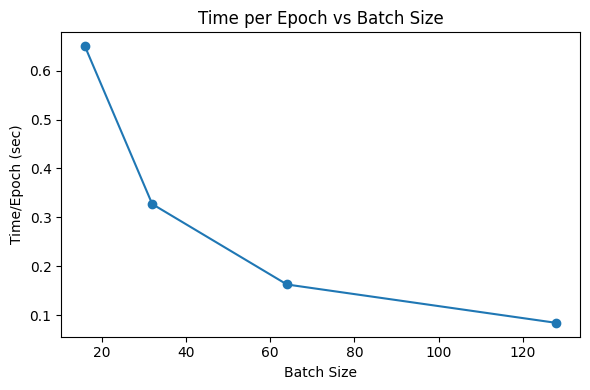

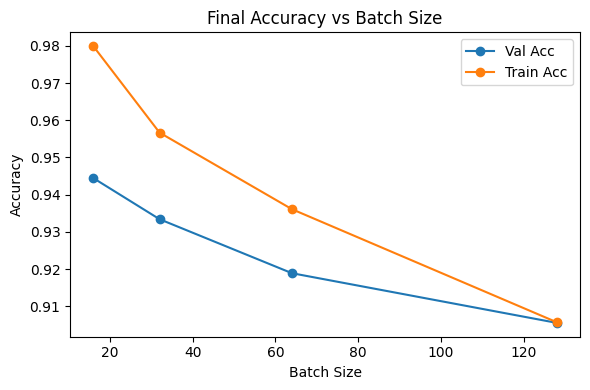

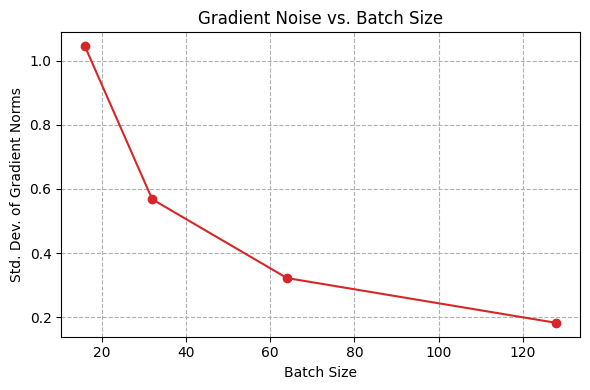

In [93]:
# Plots
plt.figure(figsize=(6, 4))
plt.plot(df.batch_size, df.time_per_epoch_s, marker="o")
plt.title("Time per Epoch vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Time/Epoch (sec)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(df.batch_size, df.final_val_acc, marker="o", label="Val Acc")
plt.plot(df.batch_size, df.final_train_acc, marker="o", label="Train Acc")
plt.title("Final Accuracy vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# --- New Plot for Gradient Noise ---
plt.figure(figsize=(6, 4))
plt.plot(df.batch_size, df.grad_norm_std, marker="o", color="tab:red")
plt.title("Gradient Noise vs. Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Std. Dev. of Gradient Norms")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

## Architecture Analysis:

### Analysis by number of layers

In [ ]:
# Architectures to test: 2, 3, 4, 5 (each contains 128 layers)
layers = [
    [128, 128],
    [128, 128, 128],
    [128, 128, 128, 128],
    [128, 128, 128, 128, 128]
]
layers_results = []

for hidden_layers in layers:
    num_layers = len(hidden_layers)
    print(f"\nTesting {num_layers}-layer network: {hidden_layers}")

    # Create and place model on device
    model = customNet(INPUT_DATA_SIZE, NUM_CLASSES, hidden_layers, LEARNING_RATE)
    model.to(device)
    model.initializeWeights()

    # Measure wall-clock time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    training_stats = model.train(
        x_train, y_train,
        X_val=x_val, Y_val=y_val,
        batch_size=BATCH_SIZE,
        epochs=NUMBER_OF_EPOCHS
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()
    total_time_s = end - start
    
    layers_results.append({
        "num_layers": num_layers,
        "architecture": str(hidden_layers),
        "time_total_s": total_time_s,
        "final_train_acc": training_stats["train_acc"][-1],
        "final_val_acc": training_stats["val_acc"][-1],
    })

# Create and display the comparison table for layers
layers_df = pd.DataFrame(layers_results)
display(layers_df)


Testing 2-layer network: [128, 128]
-> Epoch 1, Total Loss: 1.5291802641711658,  Total Evaluation Loss: 0.8477939367294312
-> Model Training accuracy: 0.5974509803921568,  Model Evaluation Accuracy: 0.808433734939759 

-> Epoch 2, Total Loss: 0.6563239052325864,  Total Evaluation Loss: 0.5289049744606018
-> Model Training accuracy: 0.8423529411764706,  Model Evaluation Accuracy: 0.8606827309236947 

-> Epoch 3, Total Loss: 0.47678131770484056,  Total Evaluation Loss: 0.43386194109916687
-> Model Training accuracy: 0.8741176470588236,  Model Evaluation Accuracy: 0.8795381526104418 

-> Epoch 4, Total Loss: 0.4048854346516766,  Total Evaluation Loss: 0.3867315351963043
-> Model Training accuracy: 0.888921568627451,  Model Evaluation Accuracy: 0.8897389558232932 

-> Epoch 5, Total Loss: 0.3626950617077984,  Total Evaluation Loss: 0.35719388723373413
-> Model Training accuracy: 0.8979411764705882,  Model Evaluation Accuracy: 0.8971285140562248 

-> Epoch 6, Total Loss: 0.3333369170940375

,num_layers,architecture,num_params,time_total_s,final_train_acc,final_val_acc
0,2,"[128, 128]",118282,0.768313,0.951275,0.929096
1,3,"[128, 128, 128]",134794,0.851185,0.962451,0.937369
2,4,"[128, 128, 128, 128]",151306,0.994103,0.976471,0.936566
3,5,"[128, 128, 128, 128, 128]",167818,1.094430,0.988431,0.941606


### Analysis by number of Neurons per layer

In [ ]:
neurons = [
    [64, 64],
    [128, 128],
    [256, 256],
    [512, 512]
]
neuron_results = []

for hidden_layers in neurons:
    num_neurons = hidden_layers[0]
    print(f"\nTesting {num_neurons}-neuron/layer network: {hidden_layers}")

    # Create and place model on device
    model = customNet(INPUT_DATA_SIZE, NUM_CLASSES, hidden_layers, LEARNING_RATE)
    model.to(device)
    model.initializeWeights()

    # Measure wall-clock time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    training_stats = model.train(
        x_train, y_train,
        X_val=x_val, Y_val=y_val,
        batch_size=BATCH_SIZE,
        epochs=NUMBER_OF_EPOCHS
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()
    
    total_time_s = end - start
    
    neuron_results.append({
        "neurons_per_layer": num_neurons,
        "architecture": str(hidden_layers),
        "time_total_s": total_time_s,
        "final_train_acc": training_stats["train_acc"][-1],
        "final_val_acc": training_stats["val_acc"][-1],
    })

# Create and display the comparison table for width
neurons_df = pd.DataFrame(neuron_results)
display(neurons_df)


Testing 64-neuron/layer network: [64, 64]
-> Epoch 1, Total Loss: 1.6444773990896684,  Total Evaluation Loss: 0.9681987166404724
-> Model Training accuracy: 0.5361764705882353,  Model Evaluation Accuracy: 0.7706024096385542 

-> Epoch 2, Total Loss: 0.7382947825178315,  Total Evaluation Loss: 0.5706489086151123
-> Model Training accuracy: 0.8164705882352942,  Model Evaluation Accuracy: 0.8538955823293173 

-> Epoch 3, Total Loss: 0.5160171536705161,  Total Evaluation Loss: 0.4575614035129547
-> Model Training accuracy: 0.860686274509804,  Model Evaluation Accuracy: 0.874859437751004 

-> Epoch 4, Total Loss: 0.43191483654553375,  Total Evaluation Loss: 0.40473660826683044
-> Model Training accuracy: 0.8805882352941177,  Model Evaluation Accuracy: 0.8851807228915662 

-> Epoch 5, Total Loss: 0.38518474335911906,  Total Evaluation Loss: 0.373068630695343
-> Model Training accuracy: 0.8933333333333333,  Model Evaluation Accuracy: 0.8919678714859438 

-> Epoch 6, Total Loss: 0.35411990707

,neurons_per_layer,architecture,time_total_s,final_train_acc,final_val_acc
0,64,"[64, 64]",0.726508,0.942255,0.923775
1,128,"[128, 128]",0.701351,0.947941,0.930040
2,256,"[256, 256]",0.803798,0.953529,0.930823
3,512,"[512, 512]",1.113960,0.957843,0.935984


### Visualization Plots

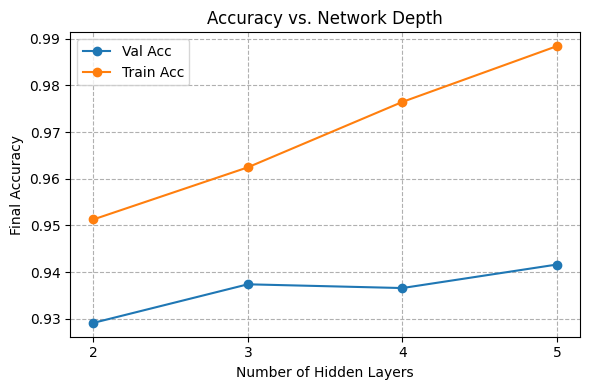

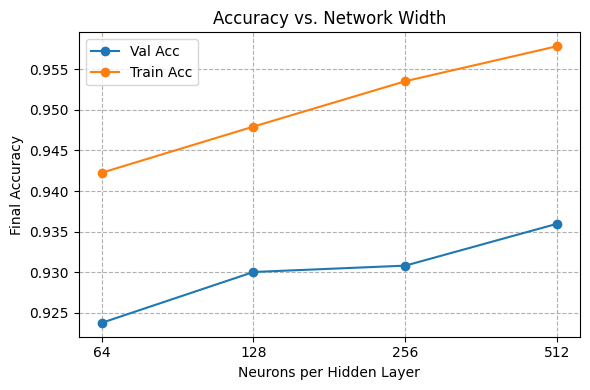

In [ ]:
# Plot for Number of Layers Analysis

plt.figure(figsize=(6, 4))
plt.plot(layers_df.num_layers, layers_df.final_val_acc, marker="o", label="Val Acc")
plt.plot(layers_df.num_layers, layers_df.final_train_acc, marker="o", label="Train Acc")
plt.title("Accuracy vs. Network Depth")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Final Accuracy")
plt.xticks(layers_df.num_layers)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Plot for Number of Neurons Analysis
plt.figure(figsize=(6, 4))
plt.plot(neurons_df.neurons_per_layer, neurons_df.final_val_acc, marker="o", label="Val Acc")
plt.plot(neurons_df.neurons_per_layer, neurons_df.final_train_acc, marker="o", label="Train Acc")
plt.title("Accuracy vs. Network Width")
plt.xlabel("Neurons per Hidden Layer")
plt.ylabel("Final Accuracy")
plt.xscale('log', base=2)
plt.xticks(neurons_df.neurons_per_layer, labels=neurons_df.neurons_per_layer)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Model Comparison

## Comparative Analysis

In [ ]:
import time
import pandas as pd
from dataLoaders import load_test
from problem1Notebook.ipynb import train_logistic, test_logistic_model, train_softmax, test_softmax, best_logistic_lr, best_softmax_lr, train_loader_binary, test_loader_binary, train_loader, test_loader

# --- 1. Best Neural Network Performance ---

# Define the best model's architecture and hyperparameters from previous analysis
best_nn_layers = [128, 128]
best_nn_lr = 0.01
best_nn_batch_size = 64
best_nn_epochs = 20

# Creating and training the best model
best_model = customNet(INPUT_DATA_SIZE, NUM_CLASSES, best_nn_layers, best_nn_lr)
best_model.to(device)
best_model.initializeWeights()

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

best_model.fit(
    X_train=x_train, Y_train=y_train,
    X_val=x_val, Y_val=y_val,
    batch_size=best_nn_batch_size,
    epochs=best_nn_epochs
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
end_time = time.perf_counter()
nn_train_time = end_time - start_time
print(f"NN Training Time: {nn_train_time:.2f} seconds")


# Load test data
x_test, y_test = load_test(pytorch=True)
x_test = x_test.to(device).float()
y_test = y_test.to(device).long()

# Evaluate on test set
print("\n--- Evaluating Best Neural Network on Test Data ---")
nn_test_loss, nn_test_acc = best_model.evaluate(x_test, y_test, best_nn_batch_size)
print(f"NN Test Loss: {nn_test_loss:.4f}, NN Test Accuracy: {nn_test_acc:.4f}")


# --- 2. Softmax Regression Performance ---
print("\n--- Training Softmax Regression ---")
start_time = time.perf_counter()
W_softmax, b_softmax = train_softmax(train_loader, epochs=200, lr=best_softmax_lr)
end_time = time.perf_counter()
softmax_train_time = end_time - start_time
print(f"Softmax Training Time: {softmax_train_time:.2f} seconds")

print("\n--- Evaluating Softmax Regression on Test Data ---")
softmax_test_loss = test_softmax(W_softmax, b_softmax, test_loader, cm_print=False)


# --- 3. Logistic Regression Performance ---
# Note: This model is for binary classification (0 vs 1) and is not directly comparable.
print("\n--- Training Logistic Regression ---")
start_time = time.perf_counter()
W_logistic, b_logistic = train_logistic(train_loader_binary, lr=best_logistic_lr, epochs=200)
end_time = time.perf_counter()
logistic_train_time = end_time - start_time
print(f"Logistic Regression Training Time: {logistic_train_time:.2f} seconds")

print("\n--- Evaluating Logistic Regression on Test Data ---")
# This function prints accuracy and returns loss
logistic_test_loss = test_logistic_model(W_logistic, b_logistic, test_loader_binary, cm_print=False)


# --- 4. Performance Summary Table ---
# Note: Logistic regression metrics are on a binary subset of data.
summary_data = {
    "Model": ["Logistic Regression", "Softmax Regression", "Neural Network (Best)"],
    "Task": ["Binary (0 vs 1)", "Multiclass (0-9)", "Multiclass (0-9)"],
    "Test Accuracy": ["99.95%", "91.61%", f"{nn_test_acc*100:.2f}%"],
    "Test Loss": [f"{logistic_test_loss:.4f}", f"{softmax_test_loss:.4f}", f"{nn_test_loss:.4f}"],
    "Training Time (s)": [f"{logistic_train_time:.2f}", f"{softmax_train_time:.2f}", f"{nn_train_time:.2f}"],
    "Complexity (Parameters)": [785, 7850, 118282]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)